             Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0  2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1  2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2  2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3  2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4  2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   

  HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday  \
0        On           Off         2.774699     Monday      No   
1        On            On        21.831384   Saturday      No   
2       Off           Off         6.764672     Sunday      No   
3       Off            On         8.623447  Wednesday      No   
4        On           Off         3.071969     Friday      No   

   EnergyConsumption  
0          75.364373  
1          83.401855  
2          78.270888  
3          56.519850  
4          70.811732  
['Timestamp', 

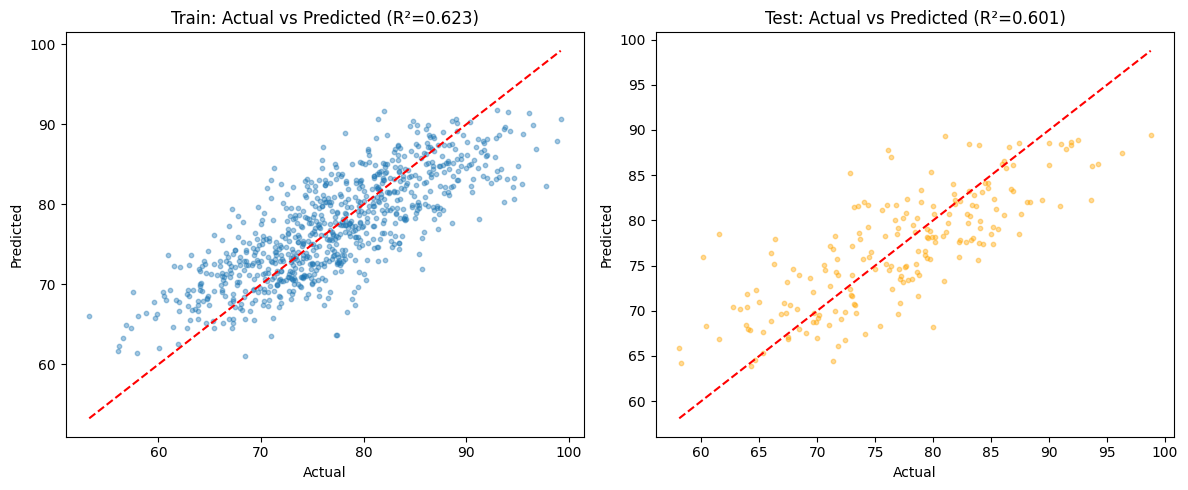

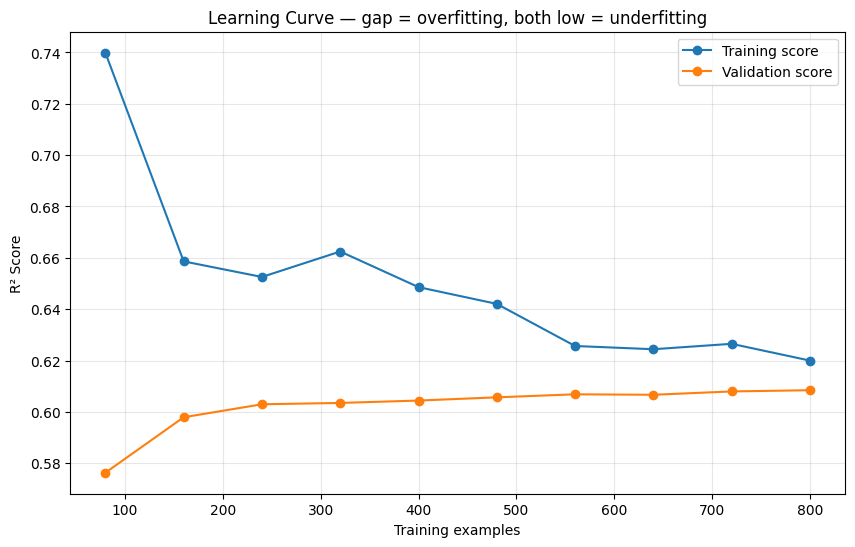

Saved model to energy_consumption_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Complete!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
from google.colab import files

DATASET_FILENAME = 'Energy_consumption.csv'
MODEL_EXPORT_NAME = 'energy_consumption_model.pkl'

try:
    df = pd.read_csv(DATASET_FILENAME)
except FileNotFoundError:
    print(f"Error: Place '{DATASET_FILENAME}' in your Colab file sidebar.")
    raise

print(df.head())
print(df.columns.tolist())
print(df.isna().sum())

TARGET_COL = 'EnergyConsumption'

NUMERIC_FEATURES = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']
CATEGORICAL_FEATURES = ['HVACUsage', 'LightingUsage']

clean_df = df.dropna(subset=NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL])

X = clean_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
Y = clean_df[TARGET_COL]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)



#ONE-HOT ENCODE CONVERTS CATEGORICAL DAATA INTO NUMPY ARRAYS

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='if_binary'), CATEGORICAL_FEATURES)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("\n--- Training model with single train-test split ---")
model.fit(X_train, Y_train)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_r2 = r2_score(Y_train, train_preds)
test_r2 = r2_score(Y_test, test_preds)
train_mae = mean_absolute_error(Y_train, train_preds)
test_mae = mean_absolute_error(Y_test, test_preds)

print(f"Train R²: {train_r2*100:.2f}% | Test R²: {test_r2*100:.2f}%")
print(f"Train MAE: {train_mae:.2f} | Test MAE: {test_mae:.2f}")
print("(Big gap between train and test = overfitting. Close scores = good generalization.)")


# K-FOLD CROSS-VALIDATION
K = 5
R2_SCORES = []
MEAN_ABS_ERRORS = []

K_FOLDS = KFold(n_splits=K, shuffle=True, random_state=42)

print(f"\n--- Performing {K}-Fold Cross-Validation ---")

for fold, (train_index, test_index) in enumerate(K_FOLDS.split(X)):
    print(f"\n --- Fold {fold+1}/{K} ---")
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    Y_train_fold, Y_test_fold = Y.iloc[train_index], Y.iloc[test_index]

    print(f"Training rows: {X_train_fold.shape[0]} | Testing rows: {X_test_fold.shape[0]}")

    # Re-initialize the pipeline for each fold to ensure a fresh model
    fold_model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    fold_model.fit(X_train_fold, Y_train_fold)
    predictions_fold = fold_model.predict(X_test_fold)

    score_r2_fold = r2_score(Y_test_fold, predictions_fold)
    mae_fold = mean_absolute_error(Y_test_fold, predictions_fold)

    R2_SCORES.append(score_r2_fold)
    MEAN_ABS_ERRORS.append(mae_fold)

    print(f"R² Fit Accuracy Score (Fold {fold+1}): {score_r2_fold * 100:.2f}%")
    print(f"Mean Absolute Error (Fold {fold+1}): {mae_fold:.2f} Panels")

print("\n=== CROSS-VALIDATION SUMMARY ===")
print(f"Average R² Fit Accuracy Score: {np.mean(R2_SCORES) * 100:.2f}%")
print(f"Standard Deviation of R²: {np.std(R2_SCORES) * 100:.2f}%")
print(f"Average Mean Absolute Error: {np.mean(MEAN_ABS_ERRORS):.2f} Panels")
print(f"Standard Deviation of MAE: {np.std(MEAN_ABS_ERRORS):.2f} Panels")


# ============ PLOT 1: Actual vs Predicted (train vs test) ============
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Y_train, train_preds, alpha=0.4, s=10)
axes[0].plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
axes[0].set_title(f'Train: Actual vs Predicted (R²={train_r2:.3f})')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(Y_test, test_preds, alpha=0.4, s=10, color='orange')
axes[1].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
axes[1].set_title(f'Test: Actual vs Predicted (R²={test_r2:.3f})')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=100)
plt.show()

# ============ PLOT 2: Learning Curve ============
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X,
    y=Y,
    cv=K_FOLDS,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig_lc = plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', marker='o')

plt.plot(train_sizes, val_mean, label='Validation score', marker='o')

plt.title('Learning Curve \u2014 gap = overfitting, both low = underfitting')
plt.xlabel('Training examples')
plt.ylabel('R² Score')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.savefig('learning_curve.png', dpi=100)
plt.show()


joblib.dump(model, MODEL_EXPORT_NAME)
print(f"Saved model to {MODEL_EXPORT_NAME}")
files.download(MODEL_EXPORT_NAME)
print("Complete!")